In [82]:
import matplotlib.pyplot as plt 
import matplotlib as mlib 
import numpy as np 
import japanize_matplotlib 

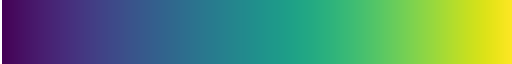

In [77]:
cmap = mlib.cm.viridis
colors = cmap(np.linspace(0, 1, 256))
colors[0, 3] = 0
alt_cmap =  mlib.colors.ListedColormap(colors)
alt_cmap

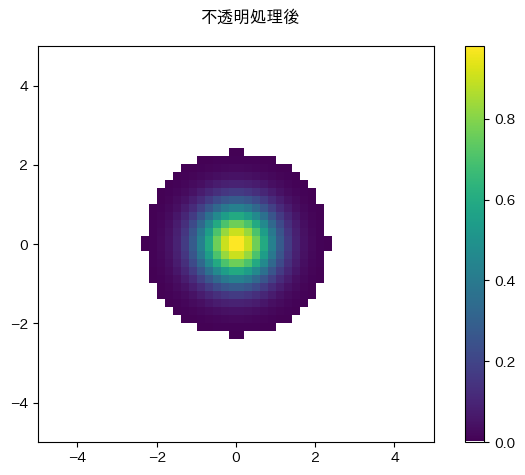

In [87]:
nx, ny = 50, 50 
x = np.linspace(-5, 5, nx)
y = np.linspace(-5, 5, ny)
X, Y = np.meshgrid(x, y)
gaussian = np.exp(-(X**2 + Y**2))
plt.imshow(gaussian, cmap= cmap, origin = 'lower',
           extent = [x.min(), x.max(), y.min(), y.max()])
plt.colorbar()
plt.suptitle("そのままのプロット")
plt.tight_layout()
plt.savefig("./_posts/images/2605/plot01.png")
plt.close()
plt.imshow(gaussian, cmap= alt_cmap, origin = 'lower',
           extent = [x.min(), x.max(), y.min(), y.max()])
plt.colorbar()
plt.suptitle("不透明処理後")
plt.tight_layout()
plt.savefig("./_posts/images/2605/plot02.png")


maskで対応する方法


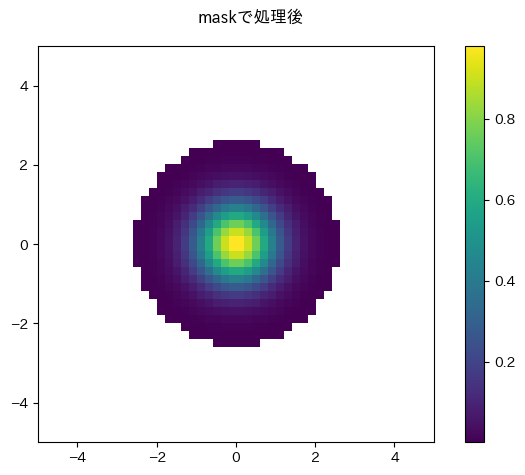

In [88]:
masked = np.ma.masked_where(gaussian <= 1e-3, gaussian)
cmap = plt.cm.viridis
cmap.set_bad(alpha = 0.0)
plt.imshow(masked, cmap=cmap, origin = 'lower',
           extent = [x.min(), x.max(), y.min(), y.max()])
plt.colorbar()
plt.suptitle("maskで処理後")
plt.tight_layout()
plt.savefig("./_posts/images/2605/plot03.png")

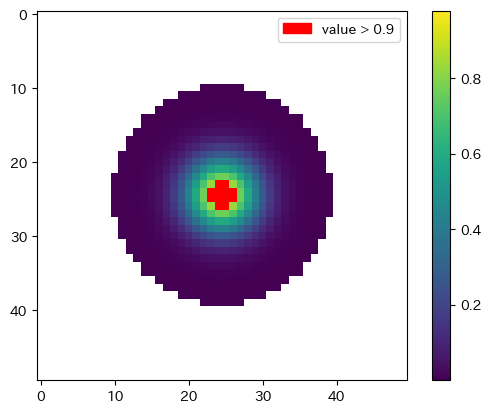

In [107]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
plt.figure()
# 0を透明にするためにmask
masked_data = np.ma.masked_where(gaussian <= 1e-4, gaussian)

cmap = plt.cm.viridis.copy()
cmap.set_bad(alpha=0.0)

plt.imshow(masked_data, cmap=cmap)
plt.colorbar()

# data == 1 の場所だけ赤で上書き
red_mask = np.ma.masked_where(gaussian < 1-1e-1, np.ones_like(gaussian))

red_cmap = ListedColormap([
    (1.0, 0.0, 0.0, 1.0)
])

im = plt.imshow(red_mask, cmap=red_cmap)
legend_elements = [
    Patch(facecolor="red", edgecolor="red", label="value > 0.9")
]
plt.legend(handles=legend_elements, loc="upper right")

plt.savefig("./_posts/images/2605/plot04.png")

plt.show()